Importing Dependecies

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import streamlit as st
import pickle
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report

Data Loading and Cleaning
- Changing column header names to "label" and "message"
- Converting labels to 0 for ham and 1 for spam
- Removing duplicate messages


In [2]:
def load_clean_data(filepath):
    data = pd.read_csv(filepath, encoding='latin-1')
    data = data[['v1', 'v2']]
    data.columns = ['label', 'message']
    data['label'] = data['label'].map({'ham': 0, 'spam': 1})
    data = data.drop_duplicates(subset='message')
    print(f"Dataset size after cleaning: {len(data)}")
    print(data['label'].value_counts().rename({0:'ham', 1:'spam'}))
    return data

data = load_clean_data('spam.csv')

Dataset size after cleaning: 5169
label
ham     4516
spam     653
Name: count, dtype: int64


Splitting Data

In [3]:
X=data["message"]
Y=data["label"]
x_train, x_test, y_train, y_test=train_test_split(X,Y, test_size=0.2, random_state=42, stratify=Y)

Vectorizing text data using TF-IDF vectorizer

In [4]:
tfidf=TfidfVectorizer(stop_words="english", lowercase=True)
x_train_v=tfidf.fit_transform(x_train)
x_test_v=tfidf.transform(x_test)

MODELS
- Model 1 - MULTINOMIAL NAIVE BAYES 
- Model 2 - LOGISTIC REGRESSION
- Model 3 - LINEAR SUPPORT VECTOR MACHINE (SVM) CLASSIFICATION

In [5]:
model1=MultinomialNB()
model2=LogisticRegression()
model3=LinearSVC(class_weight="balanced")

Test and Train using fit() and predict()

In [6]:
def train_and_test(model):
    y_pred=model.fit(x_train_v, y_train).predict(x_test_v)
    return y_pred

Prediction System

In [7]:
def prediction_system(model, messages=None):
    if messages is None:
        messages = ["Win a FREE iPhone now!",
        "Call this number to claim your prize",
        "Hey I'll call you later"]

    print("Messages :")
    for message in messages:
        print(" - " + message)

    msg_v=tfidf.transform(messages)
    pred=model.predict(msg_v)
    
    print("\nPredictions : ")    
    for message, p in zip(messages, pred):
        label="Spam" if p==1 else "Ham"
        print(f"{label} : {message}") 

    if hasattr(model, "predict_proba"):  # svm doesnt support predict_proba()
        print("\nPredicted probability : ")
        probability=model.predict_proba(msg_v)
        for message, prob in zip(messages, probability):
            print(f"{message[:30]:<30} -> Ham : {prob[0]:.2f}   Spam : {prob[1]:.2f}")

train_and_test(model1)
prediction_system(model1)

Messages :
 - Win a FREE iPhone now!
 - Call this number to claim your prize
 - Hey I'll call you later

Predictions : 
Ham : Win a FREE iPhone now!
Spam : Call this number to claim your prize
Ham : Hey I'll call you later

Predicted probability : 
Win a FREE iPhone now!         -> Ham : 0.65   Spam : 0.35
Call this number to claim your -> Ham : 0.20   Spam : 0.80
Hey I'll call you later        -> Ham : 1.00   Spam : 0.00


Evaluation


  Naive Bayes


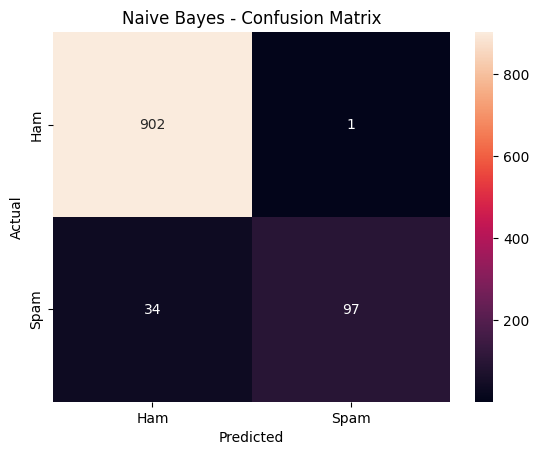

Classification Report : 
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034


  Logistic Regression


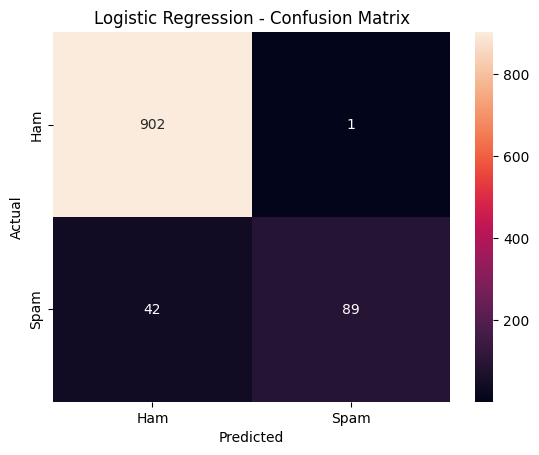

Classification Report : 
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.99      0.68      0.81       131

    accuracy                           0.96      1034
   macro avg       0.97      0.84      0.89      1034
weighted avg       0.96      0.96      0.96      1034


  Linear SVC


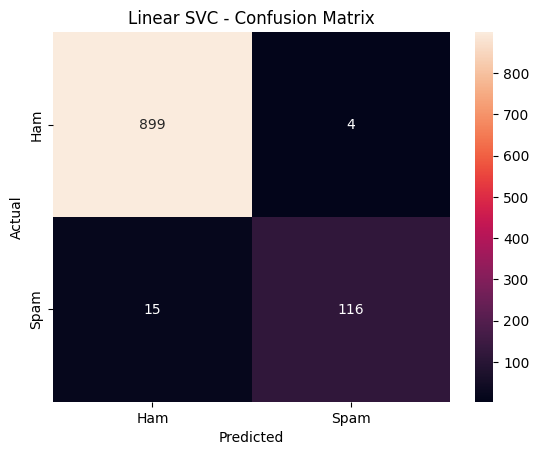

Classification Report : 
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.97      0.89      0.92       131

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [8]:
def evaluate_models(models, names):
    for model, name in zip(models, names):

        print(f"\n{'='*40}")
        print(f"  {name}")
        print(f"{'='*40}")

        y_pred = train_and_test(model)

        cm = confusion_matrix(y_test, y_pred)
        plt.figure()
        sns.heatmap(cm, annot=True, fmt='d',
                    xticklabels=['Ham', 'Spam'],
                    yticklabels=['Ham', 'Spam'])
        plt.title(f"{name} - Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

        print("Classification Report : ")
        print(classification_report(y_test, y_pred))


evaluate_models(
    [model1, model2, model3],
    ['Naive Bayes', 'Logistic Regression', 'Linear SVC']
)

Feature Analysis

In [9]:
def plot_top_words(model, tfidf, n=20):
    feature_names = tfidf.get_feature_names_out()
    spam_weights = model.feature_log_prob_[1]
    ham_weights = model.feature_log_prob_[0]
    diff_weights = spam_weights - ham_weights

    top_spam_idx = np.argsort(diff_weights)[-n:][::-1]
    top_ham_idx = np.argsort(diff_weights)[:n][::-1]

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    sns.barplot(x=feature_names[top_spam_idx], y=diff_weights[top_spam_idx], color='red', ax=axes[0])
    axes[0].set_title(f"Top {n} Spam Words")
    axes[0].tick_params(axis='x', rotation=45)

    sns.barplot(x=feature_names[top_ham_idx], y=diff_weights[top_ham_idx], color='green', ax=axes[1])
    axes[1].set_title(f"Top {n} Ham Words")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

Note : Some HTML artifacts (gt, lt) appear in the top ham words 
due to unescaped HTML in the raw dataset. These could be removed using text preprocessing.

In [ ]:
with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('model1_nb.pkl', 'wb') as f:
    pickle.dump(model1, f)

with open('model2_lr.pkl', 'wb') as f:
    pickle.dump(model2, f)

with open('model3_svm.pkl', 'wb') as f:
    pickle.dump(model3, f)